In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data = pd.read_excel('fundamental_data_election.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   election_date              561 non-null    datetime64[ns]
 1   election_year              561 non-null    int64         
 2   democratic_vote_share_adj  510 non-null    float64       
 3   republican_vote_share_adj  510 non-null    float64       
 4   state                      561 non-null    object        
 5   state_name                 561 non-null    object        
 6   region                     561 non-null    object        
 7   electoral_votes            561 non-null    int64         
 8   PVI                        561 non-null    float64       
 9   state_unemployment         561 non-null    float64       
 10  state_house_price          561 non-null    float64       
 11  state_med_income           459 non-null    float64       
 12  state_pe

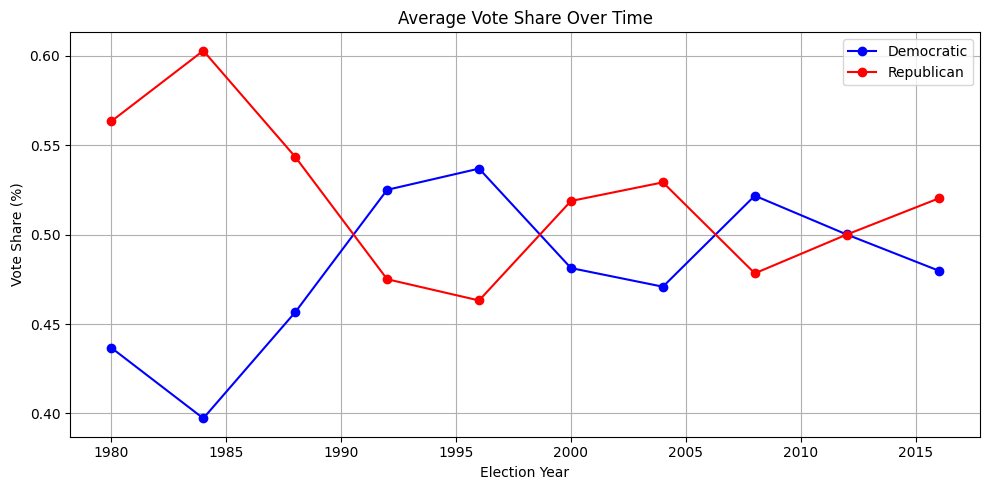

Average Democratic Vote From 1980-2020: 0.4806
Average Republican Vote From 1980-2020: 0.5194


In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
data = pd.read_excel("fundamental_data_election.xlsx", engine="openpyxl")

# Select vote share columns
vote_trend = data.iloc[:, list(range(1, 4))]  # election_year, democratic_vote_share_adj, republican_vote_share_adj

# Calculate average vote shares
average_democratic = vote_trend.iloc[:, 1].mean()
average_republican = vote_trend.iloc[:, 2].mean()

# Group by election year and calculate average vote shares
vote_avg = data.groupby("election_year")[["democratic_vote_share_adj", "republican_vote_share_adj"]].mean()

# Plot Democratic vote share over time
plt.figure(figsize=(10, 5))
plt.plot(vote_avg.index, vote_avg["democratic_vote_share_adj"], marker='o', color='blue', label='Democratic')
plt.plot(vote_avg.index, vote_avg["republican_vote_share_adj"], marker='o', color='red', label='Republican')
plt.title("Average Vote Share Over Time")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Print average vote shares
print(f"Average Democratic Vote From 1980-2020: {average_democratic:.4f}")
print(f"Average Republican Vote From 1980-2020: {average_republican:.4f}")



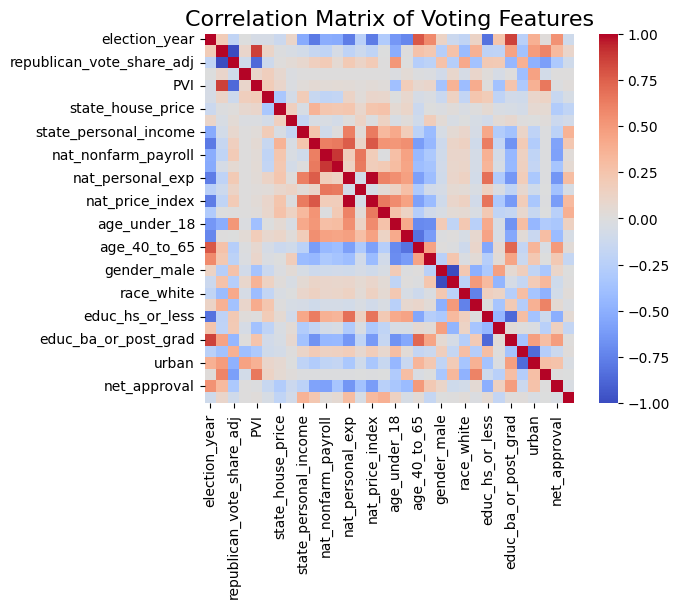

<Figure size 2000x5000 with 0 Axes>

In [89]:
numeric_data = data.select_dtypes(include='number')
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Voting Features", fontsize=16)
plt.figure(figsize=(20, 50))
plt.tight_layout()

In [115]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Select relevant features based on high correlation
features = ["PVI", "density", "age_under_18"]
target_dem = "democratic_vote_share_adj"
target_rep = "republican_vote_share_adj"

# Drop rows with missing values in selected columns
model_data = data[features + [target_dem, target_rep]].dropna()

# Split data into features and targets
X = model_data[features]
y_dem = model_data[target_dem]
y_rep = model_data[target_rep]

# Split into training and testing sets
X_train_dem, X_test_dem, y_train_dem, y_test_dem = train_test_split(X, y_dem, test_size=0.2, random_state=42)
X_train_rep, X_test_rep, y_train_rep, y_test_rep = train_test_split(X, y_rep, test_size=0.2, random_state=42)

# Train models
model_dem = LinearRegression()
model_rep = LinearRegression()

model_dem.fit(X_train_dem, y_train_dem)
model_rep.fit(X_train_rep, y_train_rep)

# Predict and evaluate
y_pred_dem = model_dem.predict(X_test_dem)
y_pred_rep = model_rep.predict(X_test_rep)

r2_dem = r2_score(y_test_dem, y_pred_dem)
r2_rep = r2_score(y_test_rep, y_pred_rep)

#Print results
print(f"R² score for Democratic & Republican vote share model: {r2_dem:.4f}, {r2_rep:.4f}")




R² score for Democratic & Republican vote share model: 0.8529, 0.8529


In [116]:
from sklearn.metrics import mean_squared_error

# Drop NA values
data_clean = data.dropna(subset=["PVI", "density", "age_under_18", "democratic_vote_share_adj", "republican_vote_share_adj"])
features = data_clean[["PVI", "density", "age_under_18"]]

# Target variables
target_dem = data_clean["democratic_vote_share_adj"]
target_rep = data_clean["republican_vote_share_adj"]

# Fit models
model_dem = LinearRegression().fit(features, target_dem)
model_rep = LinearRegression().fit(features, target_rep)

# Make predictions
pred_dem = model_dem.predict(features)
pred_rep = model_rep.predict(features)

# Calculate MSE
mse_dem = mean_squared_error(target_dem, pred_dem)
mse_rep = mean_squared_error(target_rep, pred_rep)

# Print results
print(f"MSE scores – Democratic: {mse_dem:.4f}, Republican: {mse_rep:.4f}")


MSE scores – Democratic: 0.0027, Republican: 0.0027


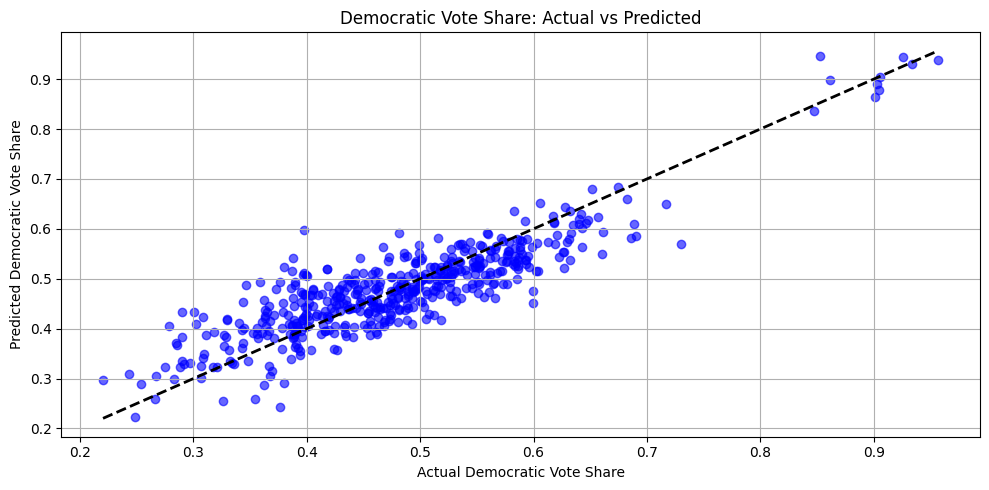

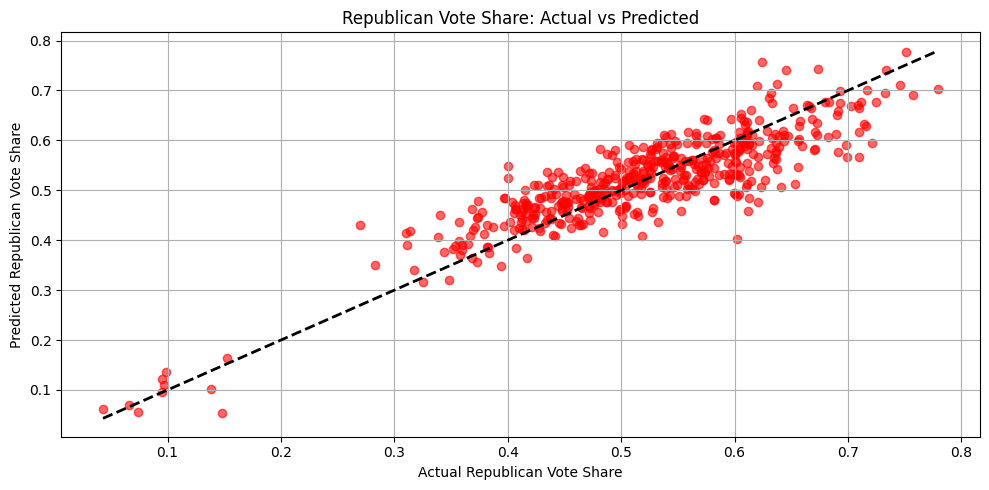

In [105]:
import matplotlib.pyplot as plt

# Democratic Vote Share
plt.figure(figsize=(10, 5))
plt.scatter(target_dem, pred_dem, color='blue', alpha=0.6)
plt.plot([target_dem.min(), target_dem.max()], [target_dem.min(), target_dem.max()], 'k--', lw=2)
plt.xlabel("Actual Democratic Vote Share")
plt.ylabel("Predicted Democratic Vote Share")
plt.title("Democratic Vote Share: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# Republican Vote Share
plt.figure(figsize=(10, 5))
plt.scatter(target_rep, pred_rep, color='red', alpha=0.6)
plt.plot([target_rep.min(), target_rep.max()], [target_rep.min(), target_rep.max()], 'k--', lw=2)
plt.xlabel("Actual Republican Vote Share")
plt.ylabel("Predicted Republican Vote Share")
plt.title("Republican Vote Share: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()



In [112]:
# Group by election year and calculate actual and predicted averages
results = data_clean.groupby("election_year")[["democratic_vote_share_adj", "pred_democratic", "republican_vote_share_adj", "pred_republican"]].mean().reset_index()

# Rename columns for clarity
results.columns = ["Election Year", "Actual Democratic", "Predicted Democratic", "Actual Republican", "Predicted Republican"]

for col in results.columns[1:]:
    results[col] = (results[col] * 100).round().astype(str) + '%'

# Display the results
results_rounded = results.round(4)

# Format as a table
print(results_rounded.to_string(index=False))




 Election Year Actual Democratic Predicted Democratic Actual Republican Predicted Republican
          1980             44.0%                46.0%             56.0%                54.0%
          1984             40.0%                47.0%             60.0%                53.0%
          1988             46.0%                48.0%             54.0%                52.0%
          1992             52.0%                48.0%             48.0%                52.0%
          1996             54.0%                48.0%             46.0%                52.0%
          2000             48.0%                48.0%             52.0%                52.0%
          2004             47.0%                48.0%             53.0%                52.0%
          2008             52.0%                49.0%             48.0%                51.0%
          2012             50.0%                49.0%             50.0%                51.0%
          2016             48.0%                50.0%             52.0

In [125]:
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_excel("fundamental_data_election.xlsx", engine="openpyxl")

# Define the features to use
features = [
    "PVI", "density", "age_under_18", "age_18_to_40", "age_40_to_65", "age_65_plus",
    "gender_male", "gender_female", "race_white", "race_black",
    "educ_hs_or_less", "educ_less_than_4_yrs", "educ_ba_or_post_grad",
    "state_unemployment", "state_house_price", "state_med_income", "state_personal_income",
    "nat_gdp", "nat_nonfarm_payroll", "nat_ind_production", "nat_personal_exp",
    "nat_personal_inc", "nat_price_index", "stock_market",
    "nonurban", "urban", "net_approval", "incumbent"
]

# Drop rows with missing values in selected features and vote shares
df_clean = df.dropna(subset=features + ["democratic_vote_share_adj", "republican_vote_share_adj"]).copy()

# Infer the winning party based on vote shares
df_clean.loc[:, "Winning Party"] = df_clean.apply(
    lambda row: "Democratic" if row["democratic_vote_share_adj"] > row["republican_vote_share_adj"] else "Republican",
    axis=1
)

# Prepare training data (exclude 2020 for prediction)
train_data = df_clean[df_clean["election_year"] < 2020]
X_train = train_data[features]
y_train = train_data["Winning Party"]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_encoded)

# Prepare 2020 data for prediction
data_2020 = df[df["election_year"] == 2020].dropna(subset=features)
if not data_2020.empty:
    X_2020 = data_2020[features]
    pred_2020 = model.predict(X_2020)
    predicted_party_2020 = le.inverse_transform(pred_2020)
    unique_prediction = pd.Series(predicted_party_2020).mode()[0]
    print(f"Predicted Winning Party In 2020 Election: {unique_prediction}")
else:
    print("No complete data available for 2020 election prediction.")



Predicted Winning Party In 2020 Election: Democratic


In [126]:
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_excel("fundamental_data_election.xlsx", engine="openpyxl")

# Define the features to use
features = [
    "PVI", "density", "age_under_18", "age_18_to_40", "age_40_to_65", "age_65_plus",
    "gender_male", "gender_female", "race_white", "race_black",
    "educ_hs_or_less", "educ_less_than_4_yrs", "educ_ba_or_post_grad",
    "state_unemployment", "state_house_price", "state_med_income", "state_personal_income",
    "nat_gdp", "nat_nonfarm_payroll", "nat_ind_production", "nat_personal_exp",
    "nat_personal_inc", "nat_price_index", "stock_market",
    "nonurban", "urban", "net_approval", "incumbent"
]

# Drop rows with missing values in selected features and vote shares
df_clean = df.dropna(subset=features + ["democratic_vote_share_adj", "republican_vote_share_adj"])

# Infer the winning party based on vote shares
df_clean.loc[:, "Winning Party"] = df_clean.apply(
    lambda row: "Democratic" if row["democratic_vote_share_adj"] > row["republican_vote_share_adj"] else "Republican",
    axis=1
)

# Prepare training data (exclude 2020 for prediction)
train_data = df_clean[df_clean["election_year"] < 2020]
X_train = train_data[features]
y_train = train_data["Winning Party"]

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_train)

# Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_encoded)

# Predict winning party for all election years from 1980 to 2020
all_years = df_clean[df_clean["election_year"].isin(range(1980, 2021, 4))]
X_all = all_years[features]
pred_all = model.predict(X_all)
predicted_parties = le.inverse_transform(pred_all)

# Create results table
results_table = pd.DataFrame({
    "Election Year": all_years["election_year"].values,
    "Predicted Winning Party": predicted_parties
})

# Aggregate by election year using mode
final_predictions = results_table.groupby("Election Year")["Predicted Winning Party"].agg(lambda x: x.mode()[0]).reset_index()

# Display the final summary table
print(final_predictions.to_string(index=False))



C:\Users\as77475\AppData\Local\Temp\ipykernel_21984\3888146260.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.loc[:, "Winning Party"] = df_clean.apply(


 Election Year Predicted Winning Party
          1988              Republican
          1992              Democratic
          1996              Democratic
          2000              Republican
          2004              Republican
          2008              Democratic
          2012              Democratic
          2016              Republican
